# Tutorial 4: Unstructured Pruning on Bert

Pruning is a technique used to reduce the size and complexity of neural networks by removing unnecessary parameters (weights and connections) or structural components (neurons, filters, or layers). The goal is to create a smaller, more efficient model that maintains most of the original model's performance. The following benefits can be seen from pruning neural networks:

- **Reduce model size**: Deep neural networks often have millions of parameters, leading to large storage requirements.

- **Decrease inference time**: Fewer parameters mean fewer computations, resulting in faster predictions.

- **Improve generalization**: Removing unnecessary connections can help prevent overfitting.

- **Energy efficiency**: Smaller models require less energy to run, which is crucial for edge devices and mobile applications.

Structured pruning removes entire structures (e.g., channels, filters, or layers) from the network, while unstructured pruning removes individual weights or connections from the network, regardless of their location. In this tutorial, we'll build on top of Tutorial 3 by taking the quantized Bert model and running Mase's unstructured pruning pass. After pruning, we'll run further fine tuning iterations to retain sequence classification accuracy in the pruned model.

In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [2]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names

tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on Quantization-Aware Training (QAT), run the following cell to import the fine tuned checkpoint.

In [3]:
from pathlib import Path
from chop import MaseGraph

mg = MaseGraph.from_checkpoint(f"/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_qat")

## Unstructured Pruning

Before running pruning, let's evaluate the model accuracy on the IMDb dataset. If you're coming from Tutorial, this would be the same as the accuracy after Quantization Aware Training (QAT). If you've just initialized the model, this will likely be a random guess (i.e. around 50%), in which case pruning wouldn't have a significant effect on the accuracy.

In [4]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/src/chop/tools/huggingface.py:160: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.8444


To run the pruning pass, we pass the following pruning configuration dictionary, which defines the following parameters.

- **Sparsity**: a value between 0 and 1, expressing the proportion of elements in the model that should be pruned (i.e. set to 0).

- **Method**: several pruning methods are supported, including ``Random`` and ``L1-Norm``.

- **Scope**: defines whether to consider each weight/activation tensor individually (``local``) or all tensors in the model (``global``) when obtaining statistics for pruning (e.g. absolute value threshold for pruning)

We'll start by running random pruning with local scope, at a fixed sparsity. This may be suboptimal, but in future tutorials we'll see how to find optimal pruning and quantization configurations for a given model on a specified dataset.

In [5]:
import chop.passes as passes

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

mg, _ = passes.prune_transform_pass(mg, pass_args=pruning_config)

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Let's evaluate the effect of pruning on accuracy. It's likely to observe drops of around 10% or more.

In [6]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
    num_train_epochs=5,
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/src/chop/tools/huggingface.py:160: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.67612


To overcome the drop in accuracy, we'll run a few finetuning epochs. This allows the model to adapt to the new pruning mask.

In [7]:
trainer.train()

Step,Training Loss
500,0.446700
1000,0.409600
1500,0.424500
2000,0.407700
2500,0.403200
3000,0.413300
3500,0.418100
4000,0.398000
4500,0.391100
5000,0.393500


TrainOutput(global_step=15625, training_loss=0.39343611450195315, metrics={'train_runtime': 112.3567, 'train_samples_per_second': 1112.529, 'train_steps_per_second': 139.066, 'total_flos': 0.0, 'train_loss': 0.39343611450195315, 'epoch': 5.0})

Let's evaluate the model accuracy after finetuning. We should see that the accuracy is reverted back to the original level.

In [8]:
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Evaluation accuracy: 0.83288


In [16]:
import matplotlib.pyplot as plt
import torch
import chop.tools as tools
def pruning_config(sparsity, method="l1-norm", scope="local"):
    return {
        "weight": {
            "sparsity": sparsity,
            "method": method,
            "scope": scope,
        },
        "activation": {
            "sparsity": sparsity,
            "method": method,
            "scope": scope,
        },
    }

def get_best_accuracy(trainer):
    best_acc = None

    trainer.train()

    if hasattr(trainer, "state") and hasattr(trainer.state, "log_history"):
        for rec in trainer.state.log_history:
            if "eval_accuracy" in rec:
                best_acc = (
                    rec["eval_accuracy"]
                    if best_acc is None
                    else max(best_acc, rec["eval_accuracy"])
                )

    if best_acc is None:
        best_acc = trainer.evaluate()["accuracy"]

    return best_acc


def sparsity_sweep(batch_size=8, log_path="pruning_results.txt"):
    sparsity_list = [i / 10 for i in range(1, 9)]
    random_accuracies = []
    l1_accuracies = []

    with open(log_path, "a") as f:

        print("Random pruning sweep...")
        for sparsity in sparsity_list:
            print(f"[Random] sparsity={sparsity}")

            mg = MaseGraph.from_checkpoint(
                "/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_qat"
            )
            mg, _ = passes.prune_transform_pass(
                mg, pass_args=pruning_config(sparsity, method="random")
            )

            trainer = tools.get_trainer(
                model=mg.model,
                tokenized_dataset=dataset,
                tokenizer=tokenizer,
                evaluate_metric="accuracy",
                num_train_epochs=5,
                train_batch_size=batch_size,
            )

            device = torch.device("cuda:0")
            trainer.model.to(device)
            trainer.train()

            acc = trainer.evaluate()["eval_accuracy"]
            random_accuracies.append(acc)

            f.write(f"random {sparsity:.1f} {acc:.6f}\n")
            f.flush()

        print("L1-Norm pruning sweep...")
        for sparsity in sparsity_list:
            print(f"[L1] sparsity={sparsity}")

            mg = MaseGraph.from_checkpoint(
                "/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_qat"
            )
            mg, _ = passes.prune_transform_pass(
                mg, pass_args=pruning_config(sparsity, method="l1-norm")
            )

            trainer = tools.get_trainer(
                model=mg.model,
                tokenized_dataset=dataset,
                tokenizer=tokenizer,
                evaluate_metric="accuracy",
                num_train_epochs=5,
                train_batch_size=batch_size,
            )

            device = torch.device("cuda:0")
            trainer.model.to(device)
            trainer.train()

            acc = trainer.evaluate()["eval_accuracy"]
            l1_accuracies.append(acc)

            f.write(f"l1-norm {sparsity:.1f} {acc:.6f}\n")
            f.flush()

    plt.figure(figsize=(10, 6))
    plt.plot(sparsity_list, random_accuracies, marker="o", label="Random pruning")
    plt.plot(sparsity_list, l1_accuracies, marker="o", label="L1-Norm pruning")
    plt.xlabel("Sparsity")
    plt.ylabel("Accuracy")
    plt.title("Pruning Sparsity vs Accuracy (IMDb)")
    plt.grid(True)
    plt.legend()
    plt.show()

    return sparsity_list, random_accuracies, l1_accuracies


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Random pruning sweep...
[Random] sparsity=0.1


/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/src/chop/tools/huggingface.py:160: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.443400
1000,0.423300
1500,0.405700
2000,0.402200
2500,0.401800
3000,0.394600
3500,0.389700


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


...

Step,Training Loss
500,0.620200
1000,0.553400
1500,0.496300
2000,0.471800
2500,0.466000
3000,0.461400
3500,0.452500


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


[L1] sparsity=0.8


/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/src/chop/tools/huggingface.py:160: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.682900
1000,0.671700
1500,0.658600
2000,0.644200
2500,0.635100
3000,0.623900
3500,0.621200


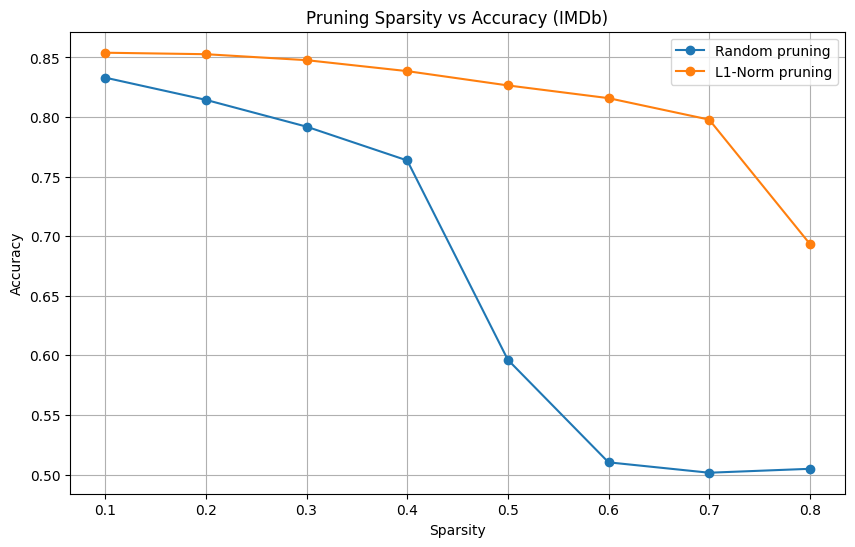

In [17]:
sparsity_list, random_accuracies, l1_accuracies = sparsity_sweep(32)

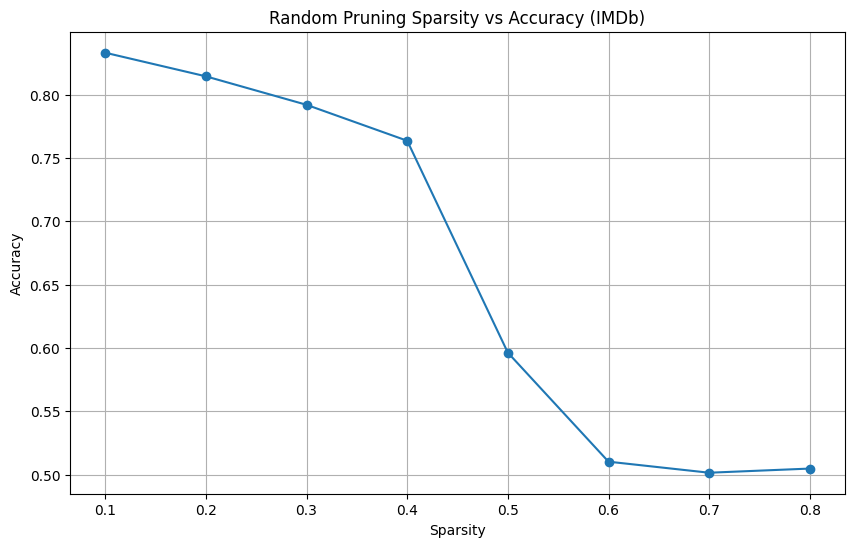

In [18]:
#plot random pruning results alone
plt.figure(figsize=(10, 6))
plt.plot(sparsity_list, random_accuracies, marker="o", label="Random pruning")
plt.xlabel("Sparsity")
plt.ylabel("Accuracy")
plt.title("Random Pruning Sparsity vs Accuracy (IMDb)")
plt.grid(True)